In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.cluster import MiniBatchKMeans
from tqdm import tqdm

In [3]:
# Total number of data points: 18.752.333
# Number of slices: 143.680
# ~ 130 data points per slice [6, 499]

#       Date	                    Texp	        size
# count	143680	                    143680.000000	143680.000000
# mean	2016-10-28  16:46:33.407572	0.540287	    130.514567
# min	2000-01-03  00:00:00	    0.002738	    6.000000
# 25%	2012-12-19  00:00:00	    0.071184	    62.000000
# 50%	2018-03-27  00:00:00	    0.238193	    115.000000
# 75%	2022-02-28  00:00:00	    0.750171	    170.000000
# max	2024-12-31  00:00:00	    6.048000	    499.000000
# std	NaN	                        0.755189	    89.166256

df = pd.read_parquet("data/ivdata.parquet")
df.head()

,Date,Texp,z,w
219043,2000-01-03,0.052019,-0.400915,NaN
219044,2000-01-03,0.052019,-0.350905,0.000097
219045,2000-01-03,0.052019,-0.326807,0.000086
219046,2000-01-03,0.052019,-0.303277,0.000076
219047,2000-01-03,0.052019,-0.280287,0.000066


In [ ]:
# distr = df.groupby(['Date', 'Texp'], as_index=False).size()

In [11]:
def f(g):
    g = g.dropna()

    return pd.Series({
        "range": g["z"].max() - g["z"].min(),
        "end": g["z"].max(),
        "start": g["z"].min()
    })

G = df.groupby(['Date', 'Texp']).apply(f)
G.head()
# R = np.random.randint(0, len(G), 1000)
# G = G.iloc[R]
# G["z"].hist(bins=100)
# n = len(G)

# for i, ((d, t), g) in tqdm(enumerate(G), total=n):
#     plt.scatter(g["z"], i * np.ones(len(g["z"])) / n, color="b")

#     if (i > 10_000):
#         break

# plt.show()

range       end     start
Date       Texp                                  
2000-01-03 0.052019  0.429563  0.078658 -0.350905
           0.128679  0.405465  0.121551 -0.283914
           0.205339  0.847298  0.176311 -0.670987
           0.454483  1.360977  0.272176 -1.088801
           0.703628  0.796005  0.281850 -0.514154

In [40]:
G[G["range"] == G["range"].min()]

,,range,end,start
Date,Texp,,,
2001-04-20,0.002738,0.0,0.001393,0.001393
2006-11-22,0.002738,0.0,-0.004319,-0.004319
2020-03-13,0.104038,0.0,-0.002195,-0.002195
2024-01-04,5.996000,0.0,-0.196115,-0.196115
2024-03-06,5.828000,0.0,-0.158901,-0.158901


In [44]:
df[(df["Date"] == "2001-04-20")& (abs(df["Texp"] - 0.002738) < 0.0001) ]

,Date,Texp,z,w
300549,2001-04-20,0.002738,-0.444894,NaN
300550,2001-04-20,0.002738,-0.384269,NaN
300551,2001-04-20,0.002738,-0.327111,NaN
300552,2001-04-20,0.002738,-0.273044,NaN
300553,2001-04-20,0.002738,-0.247068,NaN
300554,2001-04-20,0.002738,-0.216763,NaN
300555,2001-04-20,0.002738,-0.206862,NaN
300556,2001-04-20,0.002738,-0.197058,NaN
300557,2001-04-20,0.002738,-0.172960,NaN
300558,2001-04-20,0.002738,-0.149430,NaN


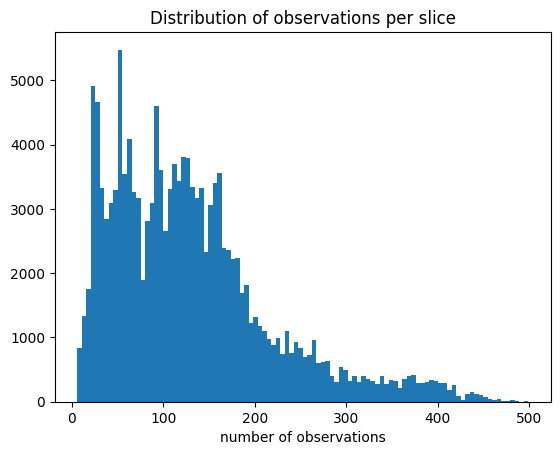

In [ ]:
S = df.groupby(['Date', 'Texp'], as_index=False).size()

plt.title("Distribution of observations per slice")

plt.hist(S["size"], bins=100)


plt.xlabel("number of observations")
# plt.savefig("images/distr_observ_per_slice.png")

In [81]:
bins = np.array([0, 7, 30, 90, 180, 365, np.inf]) / 365

labels = [
    "<=1wk",
    "1m",
    "3m",
    "6m",
    "1y",
    ">1y"
]


bindf = df.copy()
bindf["group"] = pd.cut(
    x=bindf["Texp"],
    bins=list(bins),
    labels=labels,
    include_lowest=True
)# .groupby(['Date','Texp']).size()

for g, grp in bindf.groupby("group"):
    print(g, len(grp.groupby(['Date','Texp'])))
    
# bindf.groupby("group").size()

<=1wk 10226
1m 31418
3m 31052
6m 21356
1y 27034
>1y 22594


In [ ]:
from scipy.interpolate import interp1d
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler

min_points_per_slice = 20
zgrid = np.linspace(df["z"].min(), df["z"].max(), 100)

feature_vectors = []
group_keys = []
    
for (date, texp), group in tqdm(df.groupby(['Date','Texp'])):
    group = group.dropna(subset=['z', 'w'])
    
    if len(group) < min_points_per_slice:
        continue
    
    # Option 1
    # f_interpolate = interp1d(
    #     group['z'], 
    #     group['w'], 
    #     kind='linear', 
    #     bounds_error=False, 
    #     fill_value=-1.0
    # )
    
    # w_fixed = f_interpolate(zgrid)
    
    # Option 2
    z_norm = group['z'] - group['z'].min() / (group['z'].max() - group['z'].min())
    w_fixed = np.interp(np.linspace(0, 1, 20), z_norm, group["w"])
    
    feature_vectors.append(w_fixed)
    group_keys.append((date, texp))

X = np.array(feature_vectors)

print(X.nbytes)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

100%|██████████| 143680/143680 [02:10<00:00, 1102.03it/s]


22267840


In [75]:
n_clusters=9
mbk = MiniBatchKMeans(n_clusters=n_clusters, batch_size=10_024, random_state=42, n_init="auto")
cluster_labels = mbk.fit_predict(X_scaled)
results = pd.DataFrame(group_keys, columns=['Date', 'Texp'])
results['Cluster'] = cluster_labels

In [76]:
def plot_cluster_profiles(
    X,
    cluster_labels,
    grid_points,
    n_clusters,
    overlay=False
):
    """
    Plots cluster mean profiles and variance bands.

    Parameters
    ----------
    X : ndarray, shape (n_samples, n_features)
        Feature matrix.

    cluster_labels : ndarray, shape (n_samples,)
        Cluster assignments.

    grid_points : ndarray
        Shared interpolation grid.

    n_clusters : int
        Number of clusters.

    overlay : bool, default=False
        If True, plot all cluster means in a single plot.
        If False, use a separate subplot for each cluster.
    """

    colors = plt.cm.get_cmap('tab10', n_clusters)

    #
    # Overlay plot
    #
    if overlay:

        fig, ax = plt.subplots(figsize=(10, 6))

        for i in range(n_clusters):

            cluster_data = X[cluster_labels == i]

            if len(cluster_data) == 0:
                continue

            mean_profile = np.mean(cluster_data, axis=0)
            std_profile = np.std(cluster_data, axis=0)

            ax.plot(
                grid_points,
                mean_profile,
                color=colors(i),
                linewidth=2.5,
                label=f'Cluster {i} (N={len(cluster_data)})'
            )

            ax.fill_between(
                grid_points,
                mean_profile - std_profile,
                mean_profile + std_profile,
                color=colors(i),
                alpha=0.15
            )

        ax.set_xlabel('Normalized Grid Coordinate (z)')
        ax.set_ylabel('Value (w)')
        ax.set_title('Cluster Mean Profiles')
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend()

        plt.tight_layout()
        plt.show()

        return

    #
    # Individual subplots
    #
    n_cols = min(3, n_clusters)
    n_rows = int(np.ceil(n_clusters / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5 * n_cols, 4 * n_rows),
        sharex=True,
        sharey=False
    )

    axes = np.array(axes).flatten()

    for i in range(n_clusters):

        ax = axes[i]

        cluster_data = X[cluster_labels == i]
        num_profiles = cluster_data.shape[0]

        if num_profiles == 0:
            ax.text(0.5, 0.5, "Empty Cluster",
                    ha='center', va='center')
            ax.set_title(f"Cluster {i} (N=0)")
            continue

        mean_profile = np.mean(cluster_data, axis=0)
        std_profile = np.std(cluster_data, axis=0)

        ax.fill_between(
            grid_points,
            mean_profile - std_profile,
            mean_profile + std_profile,
            color=colors(i),
            alpha=0.2,
            label='±1 Std Dev'
        )

        ax.plot(
            grid_points,
            mean_profile,
            color=colors(i),
            linewidth=2.5,
            label='Cluster Mean'
        )

        ax.set_title(
            f"Cluster {i} (N={num_profiles})",
            fontsize=12,
            fontweight='bold'
        )

        ax.grid(True, linestyle='--', alpha=0.5)

        if i == 0:
            ax.legend(loc='upper right', fontsize=9)

    for j in range(n_clusters, len(axes)):
        fig.delaxes(axes[j])

    fig.text(
        0.5,
        0.04,
        'Normalized Grid Coordinate (z)',
        ha='center',
        fontsize=12
    )

    fig.text(
        0.04,
        0.5,
        'Value (w)',
        va='center',
        rotation='vertical',
        fontsize=12
    )

    plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.95])
    plt.show()

In [77]:
plot_cluster_profiles(X, cluster_labels, np.linspace(0, 1, 20), n_clusters, False)

C:\Users\Hannes\AppData\Local\Temp\ipykernel_23004\3575718085.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_clusters)


In [53]:
merged_df = df.merge(results, on=['Date', 'Texp'], how='inner')
merged_df.head()

,Date,Texp,z,w,Cluster
0,2000-01-03,0.052019,-0.400915,NaN,3
1,2000-01-03,0.052019,-0.350905,0.000097,3
2,2000-01-03,0.052019,-0.326807,0.000086,3
3,2000-01-03,0.052019,-0.303277,0.000076,3
4,2000-01-03,0.052019,-0.280287,0.000066,3


In [ ]:
for cluster, group in merged_df.groupby("Cluster"):
    group.groupby(['Date', 'Texp']).apply()

,Date,Texp,z,w
219043,2000-01-03,0.052019,-0.400915,NaN
219044,2000-01-03,0.052019,-0.350905,0.000097
219045,2000-01-03,0.052019,-0.326807,0.000086
219046,2000-01-03,0.052019,-0.303277,0.000076
219047,2000-01-03,0.052019,-0.280287,0.000066


In [56]:
plot_cluster_means(merged_df)

C:\Users\Hannes\AppData\Local\Temp\ipykernel_23004\3777350563.py:95: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(curves, axis=0)
c:\Users\Hannes\projects\paper-revision\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\Hannes\AppData\Local\Temp\ipykernel_23004\3777350563.py:95: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(curves, axis=0)
c:\Users\Hannes\projects\paper-revision\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\Hannes\AppData\Local\Temp\ipykernel_23004\3777350563.py:95: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(curves, axis=0)
c:\Users\Hannes\projects\paper-revision\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of 

In [55]:
def plot_cluster_means(df, n_grid=200):
    """
    Plot mean curves for each cluster.

    Parameters
    ----------
    df : DataFrame
        Must contain columns
        ['Date', 'Texp', 'z', 'w', 'Cluster']

    n_grid : int
        Number of z-grid points used to construct mean curves.
    """

    clusters = sorted(df['Cluster'].dropna().unique())

    n_clusters = len(clusters)
    n_cols = min(3, n_clusters)
    n_rows = int(np.ceil(n_clusters / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5 * n_cols, 4 * n_rows),
        sharex=True,
        sharey=True
    )

    axes = np.atleast_1d(axes).flatten()

    #
    # global z-grid
    #
    z_min = df['z'].min()
    z_max = df['z'].max()

    z_grid = np.linspace(z_min, z_max, n_grid)

    for ax, cluster in zip(axes, clusters):

        cluster_df = df[df['Cluster'] == cluster]

        curves = []

        #
        # build one interpolated curve per (Date,Texp)
        #
        for (_, _), g in cluster_df.groupby(['Date', 'Texp']):

            g = (
                g[['z', 'w']]
                .dropna()
                .sort_values('z')
            )

            if len(g) < 2:
                continue

            z = g['z'].to_numpy()
            w = g['w'].to_numpy()

            #
            # remove duplicate z-values
            #
            z, idx = np.unique(z, return_index=True)
            w = w[idx]

            if len(z) < 2:
                continue

            #
            # interpolate only within observed domain
            #
            curve = np.full_like(z_grid, np.nan)

            mask = (z_grid >= z.min()) & (z_grid <= z.max())

            curve[mask] = np.interp(
                z_grid[mask],
                z,
                w
            )

            curves.append(curve)

        if len(curves) == 0:
            ax.set_title(f'Cluster {cluster}\n(no data)')
            continue

        curves = np.vstack(curves)

        #
        # equally weighted mean curve
        #
        mean_curve = np.nanmean(curves, axis=0)
        std_curve = np.nanstd(curves, axis=0)

        #
        # number of curves contributing
        #
        count = np.sum(~np.isnan(curves), axis=0)

        #
        # plot
        #
        ax.fill_between(
            z_grid,
            mean_curve - std_curve,
            mean_curve + std_curve,
            alpha=0.3
        )

        ax.plot(
            z_grid,
            mean_curve,
            linewidth=2
        )

        ax.set_title(
            f'Cluster {cluster}\n'
            f'{len(curves)} curves'
        )

        ax.grid(alpha=0.3)

    #
    # remove unused axes
    #
    for ax in axes[len(clusters):]:
        fig.delaxes(ax)

    fig.supxlabel('z')
    fig.supylabel('w')

    plt.tight_layout()
    plt.show()